https://www.kaggle.com/datasets/rockyt07/cassandra-employee-dataset

# Conjunto de dados de funcionários do Cassandra
Conjunto de dados para prática de regressão, classificação, agrupamento e EDA (Análise Exploratória de Dados).

# Sobre o conjunto de dados
📌 Bem-vindo(a) à Cassandra Systems Inc.

A Cassandra Systems Inc. é uma empresa líder em tecnologia, sediada no Vale do Silício, Califórnia, com mais de 50.000 profissionais nas áreas de engenharia, operações, RH, vendas e gestão. Este conjunto de dados oferece uma visão abrangente sobre o perfil demográfico, desempenho, satisfação, remuneração e comportamento no trabalho dos funcionários, sendo ideal para projetos de análise de RH e aprendizado de máquina no mundo real.

Arquivos disponíveis:

Employee_Complete_Dataset.csv O conjunto de dados completo contendo todos os 50.000 registros de funcionários da Cassandra Systems Inc.

Employee_Train_Dataset.csv Um subconjunto selecionado de 45.000 linhas usado para treinamento de aprendizado de máquina.

Employee_Test_Dataset.csv Um conjunto de dados de teste com 5.000 linhas para teste e avaliação comparativa do modelo.

Employee_Dataset.sql Uma versão exportada para SQL de todos os dados dos funcionários — perfeita para quem está praticando consultas SQL, junções, agregações e funções analíticas.

O que você pode fazer com este conjunto de dados: Este conjunto de dados suporta uma ampla gama de tarefas de aprendizado de máquina, como regressão, classificação e agrupamento.

Tarefas de regressão:

1. Prever o aumento salarial necessário para melhorar a satisfação dos funcionários 2. Prever quais funcionários devem ser promovidos (previsão baseada em funções) 3. Prever o salário dos funcionários 4. Prever o índice de equilíbrio entre vida pessoal e profissional 5. Prever a avaliação de desempenho

Tarefas de classificação:

1. Detectar valores discrepantes ou registros de funcionários potencialmente fraudulentos; 2. Prever a função do funcionário (classificação de funções em múltiplas classes); 3. Prever se um funcionário possui um equilíbrio saudável entre vida profissional e pessoal; 4. Prever o desempenho de funcionários de alto e baixo rendimento.

Tarefas de agrupamento:

Segmentação de Funcionários |- Agrupe funcionários usando: Idade, Salário, Anos de Experiência, Número de filhos. Projetos Passados/Atuais |- Útil para planejamento da força de trabalho, elaboração de políticas e estratégia de remuneração.

Agrupamentos de Comportamento no Trabalho |- Agrupe usando: Projetos Atuais, Projetos Anteriores, Anos de Experiência. |- Identifique perfis como Funcionários com Risco de Burnout, Profissionais de Alto Desempenho, Profissionais de Desempenho Estável, Funcionários com Treinamento Insuficiente

🚀Como você pode usar este conjunto de dados

Seja para praticar aprendizado de máquina, explorar análises de pessoas, construir modelos de previsão ou aprimorar suas habilidades em SQL, este conjunto de dados oferece tudo o que você precisa para simular o ambiente analítico de uma empresa de tecnologia real.

Escolha uma tarefa — Regressão, Classificação ou Agrupamento — e comece a descobrir os padrões ocultos dentro da Cassandra Systems Inc.

Boa modelagem e, por favor, vote positivamente neste conjunto de dados!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Employee_Complete_Dataset.csv')

print("Primeiras 5 Linhas do Dataset")
print(df.head())

print("Informações Gerais do Dataset (dtypes e non-nulls)")
df.info()

print("Colunas e Contagem de Valores Faltantes")
#Soma de valores nulos por coluna
missing_values = df.isna().sum()
print(missing_values[missing_values > 0])

Primeiras 5 Linhas do Dataset
   Employee_number   Employee_name  Employee_age  Maritial_Status  \
0            10001  Karen Anderson            36             True   
1            10002    David Taylor            34            False   
2            10003      Nina Kumar            36            False   
3            10004      John Patel            42             True   
4            10005    Emily Sharma            27             True   

   Current_Salary  Number_of_Children  years_experience  past_projects  \
0          116138                   2                12              6   
1           82171                   3                10              5   
2           48600                   1                 0              2   
3           39675                   1                 2              4   
4          161304                   3                 3             11   

   current_projects Divorced_earlier Father_alive Mother_alive  \
0                 1               No        

In [2]:
#Informações
print("Estatísticas Descritivas (Colunas Numéricas)")
print(df.describe())

Estatísticas Descritivas (Colunas Numéricas)
       Employee_number  Employee_age  Current_Salary  Number_of_Children  \
count     50000.000000  50000.000000    50000.000000         50000.00000   
mean      35000.500000     34.704800    58396.139100             1.19564   
std       14433.901067      9.607357    31415.294557             1.12194   
min       10001.000000     16.000000    15128.000000             0.00000   
25%       22500.750000     28.000000    33581.000000             0.00000   
50%       35000.500000     35.000000    53029.000000             1.00000   
75%       47500.250000     41.000000    73750.000000             2.00000   
max       60000.000000     85.000000   695267.000000             3.00000   

       years_experience  past_projects  current_projects  performance_rating  \
count      50000.000000   50000.000000       50000.00000        50000.000000   
mean           8.301700       7.013640           1.50094            3.198300   
std            8.632958       

In [3]:
#Contagem de valores únicos para 'Department'
print("Distribuição por Departamento")
print(df['Department'].value_counts())

#Contagem de valores únicos para 'Education_level'
print("Distribuição por Nível de Educação")
print(df['Education_level'].value_counts())

#Verificação da coluna 'is_outlier' (se for a variável-alvo)
print("Distribuição da Coluna 'is_outlier'")
print(df['is_outlier'].value_counts())

Distribuição por Departamento
Department
Support        7244
Sales          7232
Finance        7148
Operations     7120
Engineering    7096
R&D            7083
HR             7077
Name: count, dtype: int64
Distribuição por Nível de Educação
Education_level
Bachelor's     22633
Diploma         9957
Master's        9016
High School     7435
PhD              959
Name: count, dtype: int64
Distribuição da Coluna 'is_outlier'
is_outlier
0    49286
1      714
Name: count, dtype: int64


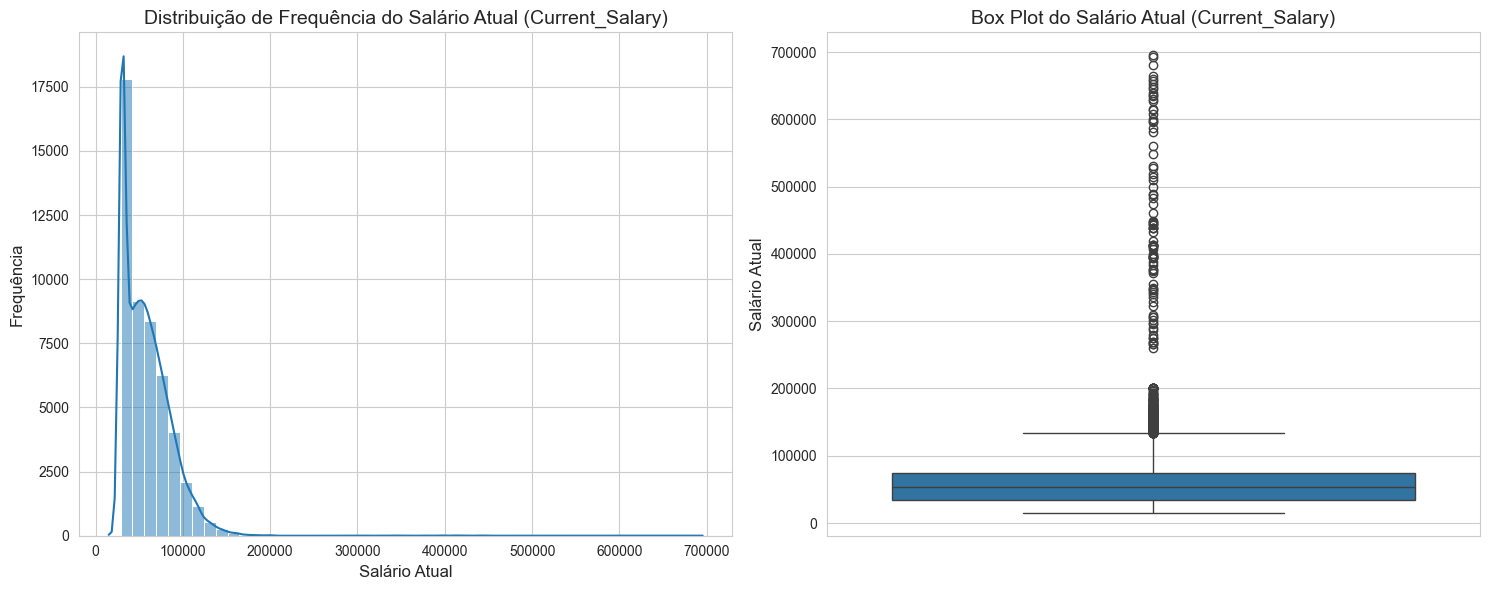

In [4]:
#Definir o estilo dos gráficos
sns.set_style("whitegrid")

#Criar a figura com dois subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Histograma do Salário
sns.histplot(df['Current_Salary'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Frequência do Salário Atual (Current_Salary)', fontsize=14)
axes[0].set_xlabel('Salário Atual', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)

#Box Plot do Salário
sns.boxplot(y=df['Current_Salary'], ax=axes[1])
axes[1].set_title('Box Plot do Salário Atual (Current_Salary)', fontsize=14)
axes[1].set_ylabel('Salário Atual', fontsize=12)

#Ajustar layout
plt.tight_layout()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_14184\2100353207.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Department', y='Current_Salary', data=df, ax=axes[0], palette='Set3')
C:\Users\Usuário\AppData\Local\Temp\ipykernel_14184\2100353207.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education_level', y='Current_Salary', data=df, order=education_order, ax=axes[1], palette='Set2')


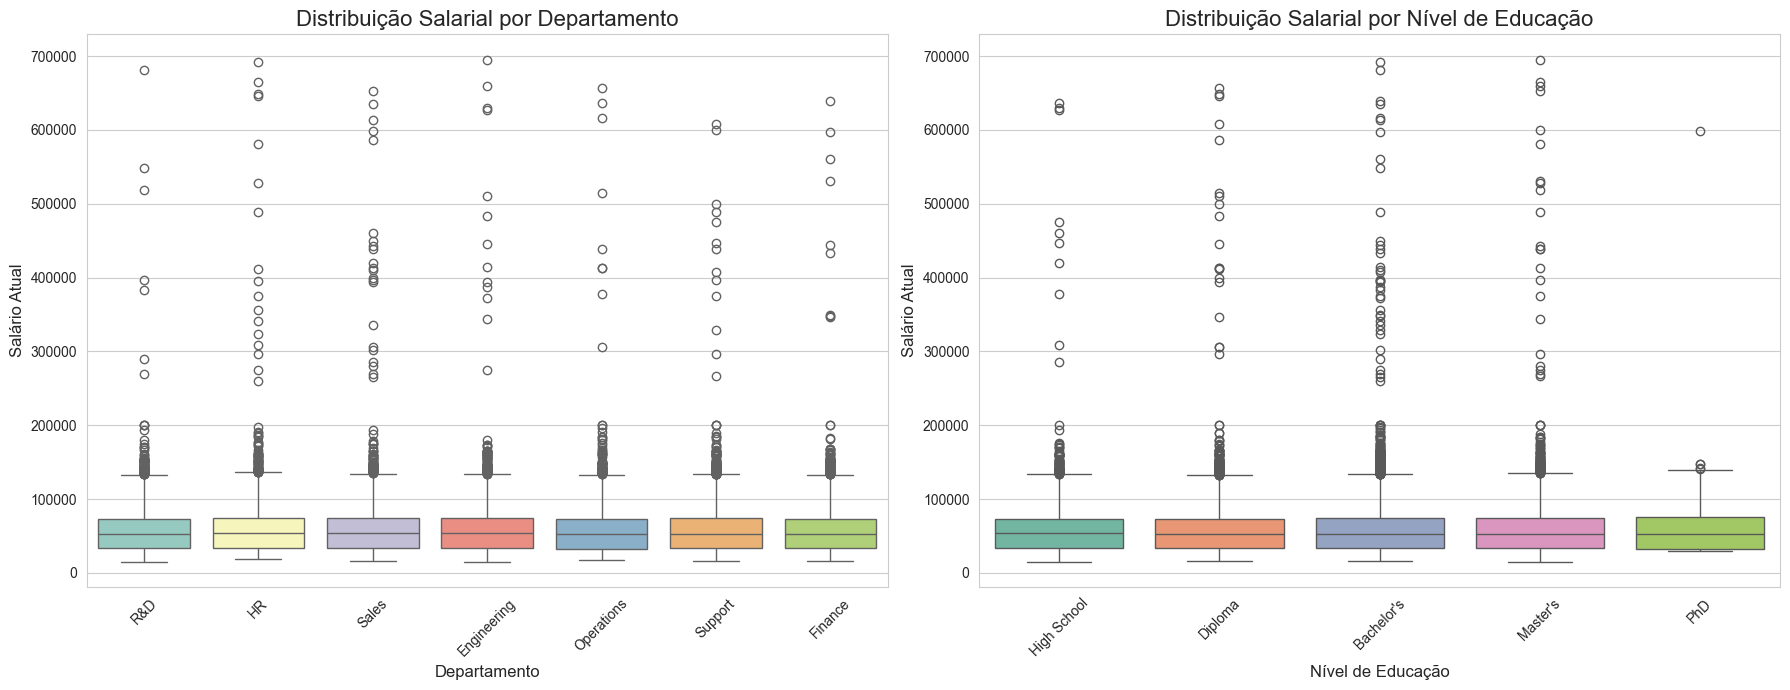

In [5]:
#Criar a figura com dois subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#Salário vs. Departamento
sns.boxplot(x='Department', y='Current_Salary', data=df, ax=axes[0], palette='Set3')
axes[0].set_title('Distribuição Salarial por Departamento', fontsize=16)
axes[0].set_xlabel('Departamento', fontsize=12)
axes[0].set_ylabel('Salário Atual', fontsize=12)
axes[0].tick_params(axis='x', rotation=45) #Gira os rótulos do eixo x para melhor visualização

#Salário vs. Nível de Educação
#Ordem personalizada para o eixo x
education_order = ["High School", "Diploma", "Bachelor's", "Master's", "PhD"]
sns.boxplot(x='Education_level', y='Current_Salary', data=df, order=education_order, ax=axes[1], palette='Set2')
axes[1].set_title('Distribuição Salarial por Nível de Educação', fontsize=16)
axes[1].set_xlabel('Nível de Educação', fontsize=12)
axes[1].set_ylabel('Salário Atual', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

#Ajustar layout
plt.tight_layout()

Matriz de Correlação (Principais Variáveis Numéricas)
                    Employee_age  Current_Salary  Number_of_Children  \
Employee_age            1.000000        0.070619           -0.000652   
Current_Salary          0.070619        1.000000            0.004928   
Number_of_Children     -0.000652        0.004928            1.000000   
years_experience        0.824120        0.056178           -0.001783   
past_projects           0.001058       -0.000574           -0.010857   
current_projects        0.004546       -0.000823            0.002874   
performance_rating      0.001011       -0.001746           -0.008638   
Job_Satisfaction        0.002851        0.322990            0.003644   
Work_Life_Balance      -0.003781        0.077274            0.003491   

                    years_experience  past_projects  current_projects  \
Employee_age                0.824120       0.001058          0.004546   
Current_Salary              0.056178      -0.000574         -0.000823   
Number

Text(0.5, 1.0, 'Mapa de Calor da Matriz de Correlação')

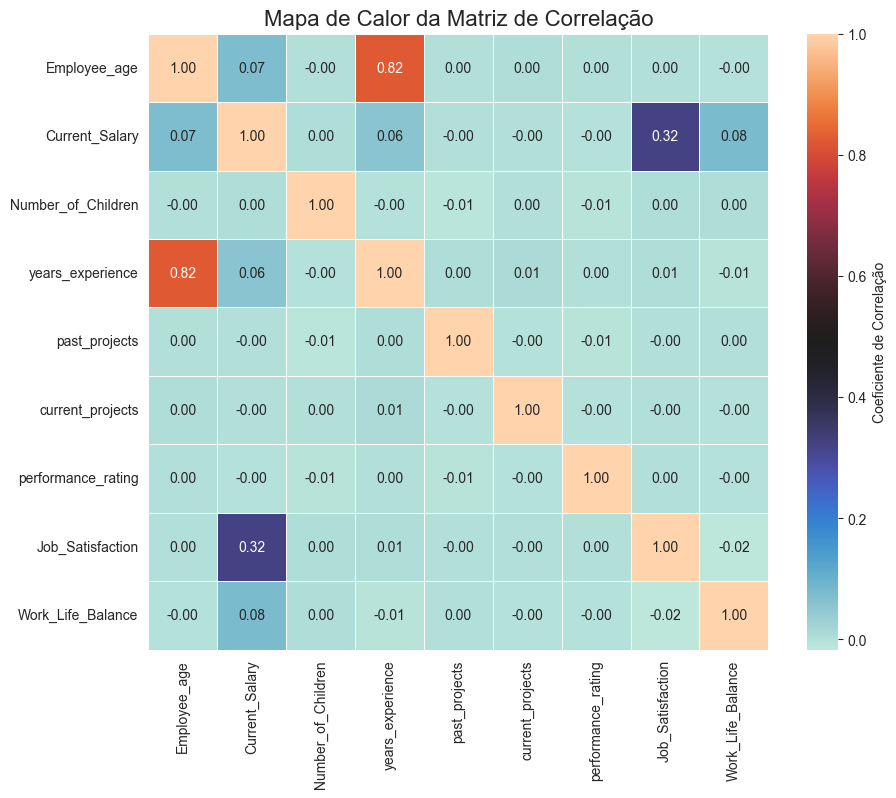

In [6]:
#Selecionar apenas as colunas numéricas (filtrando Employee_number e is_outlier para o heatmap principal)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

#Remover colunas que não são de interesse para a correlação principal (IDs e a variável-alvo)
cols_to_remove = ['Employee_number', 'is_outlier']
clean_numeric_cols = [col for col in numeric_cols if col not in cols_to_remove]

#Calcular a Matriz de Correlação
correlation_matrix = df[clean_numeric_cols].corr()

print("Matriz de Correlação (Principais Variáveis Numéricas)")
print(correlation_matrix)

#Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,        # Mostrar os valores de correlação
    cmap='icefire',   # Mapa de cores para visualização clara (vermelho/azul)
    fmt=".2f",         # Formato com 2 casas decimais
    linewidths=.5,     # Linhas entre as células
    cbar_kws={'label': 'Coeficiente de Correlação'}
)
plt.title('Mapa de Calor da Matriz de Correlação', fontsize=16)

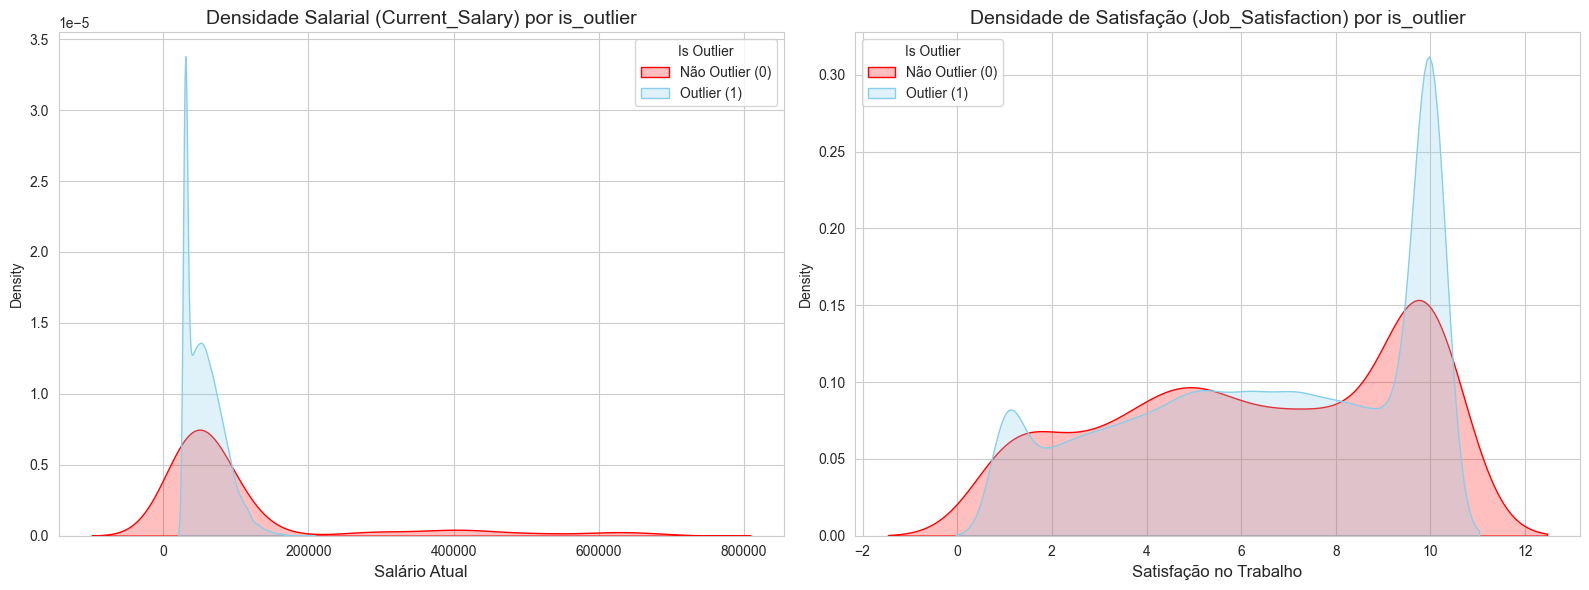

In [7]:
sns.set_style("whitegrid")

#Criar a figura com dois subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Distribuição de Salário por Outlier Status
sns.kdeplot(data=df, x='Current_Salary', hue='is_outlier', fill=True, common_norm=False, ax=axes[0], palette=['skyblue', 'red'])
axes[0].set_title('Densidade Salarial (Current_Salary) por is_outlier', fontsize=14)
axes[0].set_xlabel('Salário Atual', fontsize=12)
axes[0].legend(title='Is Outlier', labels=['Não Outlier (0)', 'Outlier (1)'])

#Distribuição de Satisfação no Trabalho por Outlier Status
sns.kdeplot(data=df, x='Job_Satisfaction', hue='is_outlier', fill=True, common_norm=False, ax=axes[1], palette=['skyblue', 'red'])
axes[1].set_title('Densidade de Satisfação (Job_Satisfaction) por is_outlier', fontsize=14)
axes[1].set_xlabel('Satisfação no Trabalho', fontsize=12)
axes[1].legend(title='Is Outlier', labels=['Não Outlier (0)', 'Outlier (1)'])

#Ajustar layout
plt.tight_layout()

# Conclusão da EAD

A Satisfação no Trabalho é o melhor indicador linear para o salário, superando a idade ou experiência. Além disso, as variáveis parecem ser muito independentes linearmente, exceto pela óbvia relação Idade-Experiência. 
Os "outliers" não são os funcionários com baixo desempenho ou baixa satisfação. São, na verdade, os funcionários com salários excepcionalmente altos e, consequentemente, alta satisfação no trabalho. Isso é vital para qualquer modelagem futura.

In [8]:
from sklearn.preprocessing import LabelEncoder

#Identificar colunas categóricas a serem codificadas
#Excluindo 'Employee_name' e 'Employee_number'
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
categorical_cols.remove('Employee_name') # Remover nome, pois é uma coluna de ID/texto

print(f"Colunas Categóricas/Booleanas a serem codificadas: {categorical_cols}")

#Codificação (Encoding)

#Label Encoding (para colunas binárias ou ordinais, se aplicável, como Education_level)
#Colunas booleanas/binárias (com 'Yes'/'No' ou True/False)
binary_cols = ['Maritial_Status', 'Divorced_earlier', 'Father_alive', 'Mother_alive']

#Substituir Yes/No e True/False por 1/0
df['Maritial_Status'] = df['Maritial_Status'].astype(int)
df['Divorced_earlier'] = df['Divorced_earlier'].map({'Yes': 1, 'No': 0})
df['Father_alive'] = df['Father_alive'].map({'Yes': 1, 'No': 0})
df['Mother_alive'] = df['Mother_alive'].map({'Yes': 1, 'No': 0})


#Ordinal Encoding para Education_level (Assume-se uma ordem hierárquica)
education_order = ["High School", "Diploma", "Bachelor's", "Master's", "PhD"]
education_mapping = {level: i + 1 for i, level in enumerate(education_order)}

df['Education_level_Encoded'] = df['Education_level'].map(education_mapping)
df.drop('Education_level', axis=1, inplace=True) # Remove a coluna original

#One-Hot Encoding para as demais categóricas (Department e Role)
#'get_dummies' do Pandas, que é mais eficiente aqui
df = pd.get_dummies(df, columns=['Department', 'Role'], prefix=['Dept', 'Role'], drop_first=True)

print("Informações do DataFrame Após Encoding")
print(df.info())
print("Primeiras 5 Linhas Após Encoding")
print(df.head())

Colunas Categóricas/Booleanas a serem codificadas: ['Maritial_Status', 'Divorced_earlier', 'Father_alive', 'Mother_alive', 'Education_level', 'Department', 'Role']
Informações do DataFrame Após Encoding
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Employee_number              50000 non-null  int64  
 1   Employee_name                50000 non-null  object 
 2   Employee_age                 50000 non-null  int64  
 3   Maritial_Status              50000 non-null  int64  
 4   Current_Salary               50000 non-null  int64  
 5   Number_of_Children           50000 non-null  int64  
 6   years_experience             50000 non-null  int64  
 7   past_projects                50000 non-null  int64  
 8   current_projects             50000 non-null  int64  
 9   Divorced_earlier             50000 non-null  

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

df_train = pd.read_csv('Employee_Train_Dataset.csv')
df_test = pd.read_csv('Employee_Test_Dataset.csv')

#Lista de colunas para o pré-processamento
ID_COLS = ['Employee_number', 'Employee_name']
OHE_COLS = ['Department', 'Role']
ORDINAL_COL = 'Education_level'
education_order = ["High School", "Diploma", "Bachelor's", "Master's", "PhD"]
education_mapping = {level: i + 1 for i, level in enumerate(education_order)}

def preprocess_data(df):
    """Aplica o pré-processamento definido (Codificação Binária e Ordinal)."""
    
    #Codificação Binária
    df['Maritial_Status'] = df['Maritial_Status'].astype(int)
    df['Divorced_earlier'] = df['Divorced_earlier'].map({'Yes': 1, 'No': 0})
    df['Father_alive'] = df['Father_alive'].map({'Yes': 1, 'No': 0})
    df['Mother_alive'] = df['Mother_alive'].map({'Yes': 1, 'No': 0})

    #Codificação Ordinal
    if ORDINAL_COL in df.columns:
        df['Education_level_Encoded'] = df[ORDINAL_COL].map(education_mapping)
        df.drop(ORDINAL_COL, axis=1, inplace=True)
    
    #Remoção de colunas de ID
    df.drop(ID_COLS, axis=1, inplace=True, errors='ignore')

    return df

#Aplicar pré-processamento
df_train_proc = preprocess_data(df_train.copy())
df_test_proc = preprocess_data(df_test.copy())

#GARANTIR COLUNAS CONSISTENTES (One-Hot Encoding) ---
#pd.get_dummies no treino e aplicamos as MESMAS colunas no teste.
df_train_proc = pd.get_dummies(df_train_proc, columns=OHE_COLS, prefix=['Dept', 'Role'], drop_first=True)
df_test_proc = pd.get_dummies(df_test_proc, columns=OHE_COLS, prefix=['Dept', 'Role'], drop_first=True)

#Alinhamento de colunas
#Adicionar colunas faltantes no teste (com valor 0) ou remover as que não estão no treino.
train_cols = set(df_train_proc.columns)
test_cols = set(df_test_proc.columns)

missing_in_test = list(train_cols - test_cols)
for col in missing_in_test:
    df_test_proc[col] = 0

df_test_proc = df_test_proc[df_train_proc.columns] # Reordena as colunas do teste

#TREINAMENTO DO MODELO COM PESOS BALANCEADOS ---

X_train = df_train_proc.drop('is_outlier', axis=1)
y_train = df_train_proc['is_outlier']
X_test = df_test_proc.drop('is_outlier', axis=1)
y_test = df_test_proc['is_outlier']

#class_weight='balanced' para tentar melhorar o Recall
model_balanced = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

#Avaliação do Modelo
y_pred_balanced = model_balanced.predict(X_test)

print("Relatório de Classificação (Regressão Logística c/ class_weight='balanced')")
print(classification_report(y_test, y_pred_balanced))

print("Matriz de Confusão")
print(confusion_matrix(y_test, y_pred_balanced))

Relatório de Classificação (Regressão Logística c/ class_weight='balanced')
              precision    recall  f1-score   support

           0       0.99      0.70      0.82      4926
           1       0.02      0.50      0.05        74

    accuracy                           0.70      5000
   macro avg       0.51      0.60      0.43      5000
weighted avg       0.98      0.70      0.81      5000

Matriz de Confusão
[[3443 1483]
 [  37   37]]


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
from sklearn.preprocessing import StandardScaler

ID_COLS = ['Employee_number', 'Employee_name']
OHE_COLS = ['Department', 'Role']
ORDINAL_COL = 'Education_level'
education_mapping = {level: i + 1 for i, level in enumerate(["High School", "Diploma", "Bachelor's", "Master's", "PhD"])}

def preprocess_data(df):
    """Aplica o pré-processamento definido (Codificação Binária e Ordinal)."""
    df['Maritial_Status'] = df['Maritial_Status'].astype(int)
    df['Divorced_earlier'] = df['Divorced_earlier'].map({'Yes': 1, 'No': 0})
    df['Father_alive'] = df['Father_alive'].map({'Yes': 1, 'No': 0})
    df['Mother_alive'] = df['Mother_alive'].map({'Yes': 1, 'No': 0})
    
    if ORDINAL_COL in df.columns:
        df['Education_level_Encoded'] = df[ORDINAL_COL].map(education_mapping)
        df.drop(ORDINAL_COL, axis=1, inplace=True)
    
    df.drop(ID_COLS, axis=1, inplace=True, errors='ignore')
    return df

df_train_proc = preprocess_data(df_train.copy())
df_test_proc = preprocess_data(df_test.copy())

#One-Hot Encoding e Alinhamento de Colunas
df_train_proc = pd.get_dummies(df_train_proc, columns=OHE_COLS, prefix=['Dept', 'Role'], drop_first=True)
df_test_proc = pd.get_dummies(df_test_proc, columns=OHE_COLS, prefix=['Dept', 'Role'], drop_first=True)

train_cols_features = df_train_proc.drop('is_outlier', axis=1).columns
df_test_proc = df_test_proc.reindex(columns=train_cols_features.tolist() + ['is_outlier'], fill_value=0)


#ESCALONAMENTO DE DADOS (StandardScaler)
X_train = df_train_proc.drop('is_outlier', axis=1)
y_train = df_train_proc['is_outlier']
X_test = df_test_proc.drop('is_outlier', axis=1)
y_test = df_test_proc['is_outlier']

#Identificar colunas numéricas para escalonamento (as que não são binárias/OHE)
#Escalonamento em todas as colunas que não são booleanas e não são OHE (pois estas já são 0/1)
cols_to_scale = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

#Excluir colunas já binárias (como as que mapeamos de True/False para int) ou colunas ordinais que não queremos escalar.
numerical_features = [
    'Employee_age', 'Current_Salary', 'Number_of_Children', 'years_experience', 
    'past_projects', 'current_projects', 'performance_rating', 'Job_Satisfaction', 
    'Work_Life_Balance', 'Education_level_Encoded' # Education_level_Encoded tem uma escala pequena, mas vamos incluir para a normalização.
]
#Garante que apenas as colunas que realmente existem em X_train sejam selecionadas
numerical_features = [col for col in numerical_features if col in X_train.columns]

#Aplicar o StandardScaler
scaler = StandardScaler()

#Ajustar (fit) o scaler APENAS no conjunto de treino e Transformar ambos
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])


#TREINAMENTO E AVALIAÇÃO DO MODELO (com pesos balanceados e dados escalados)
model_scaled_balanced = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
model_scaled_balanced.fit(X_train, y_train)

y_pred_scaled_balanced = model_scaled_balanced.predict(X_test)

print("Relatório de Classificação (Regressão Logística c/ ESCALONAMENTO e balanceamento)")
print(classification_report(y_test, y_pred_scaled_balanced))

print("Matriz de Confusão")
print(confusion_matrix(y_test, y_pred_scaled_balanced))

Relatório de Classificação (Regressão Logística c/ ESCALONAMENTO e balanceamento)
              precision    recall  f1-score   support

           0       0.99      0.70      0.82      4926
           1       0.02      0.50      0.05        74

    accuracy                           0.70      5000
   macro avg       0.51      0.60      0.43      5000
weighted avg       0.98      0.70      0.81      5000

Matriz de Confusão
[[3461 1465]
 [  37   37]]


In [11]:
from sklearn.ensemble import RandomForestClassifier

#Definição de Features (X) e Target (y)
X_train = df_train_proc.drop('is_outlier', axis=1)
y_train = df_train_proc['is_outlier']
X_test = df_test_proc.drop('is_outlier', axis=1)
y_test = df_test_proc['is_outlier']

#Treinamento do Modelo (Random Forest)
#Usando class_weight='balanced' para lidar com o desequilíbrio e um número razoável de estimadores (200)
#para tentar obter melhor desempenho que a Regressão Logística.
rf_model = RandomForestClassifier(
    n_estimators=200, 
    random_state=42, 
    class_weight='balanced',
    n_jobs=-1 # Usa todos os núcleos disponíveis para agilizar
)
rf_model.fit(X_train, y_train)

#Predição no Conjunto de Teste
y_pred_rf = rf_model.predict(X_test)

#Avaliação do Modelo
print("Relatório de Classificação (Random Forest c/ class_weight='balanced')")
print(classification_report(y_test, y_pred_rf))

print("Matriz de Confusão")
print(confusion_matrix(y_test, y_pred_rf))

Relatório de Classificação (Random Forest c/ class_weight='balanced')
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4926
           1       1.00      0.19      0.32        74

    accuracy                           0.99      5000
   macro avg       0.99      0.59      0.66      5000
weighted avg       0.99      0.99      0.98      5000

Matriz de Confusão
[[4926    0]
 [  60   14]]


# Conclusão Modelagem

Caso o objetivo for identificar outliers com absoluta certeza, o Random Forest é a melhor escolha, pois eliminou completamente os Falsos Positivos. Se o objetivo fosse encontrar o máximo possível de outliers (priorizando o Recall), a Regressão Logística seria o modelo preferido, apesar dos seus Falsos Positivos.

10 Variáveis Mais Importantes (Random Forest)
                    Feature  Importance
2            Current_Salary    0.167364
0              Employee_age    0.106939
12        Work_Life_Balance    0.104021
4          years_experience    0.101708
11         Job_Satisfaction    0.096311
5             past_projects    0.075675
10       performance_rating    0.042210
6          current_projects    0.040474
13  Education_level_Encoded    0.039999
3        Number_of_Children    0.038535


C:\Users\Usuário\AppData\Local\Temp\ipykernel_14184\65065350.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='icefire')


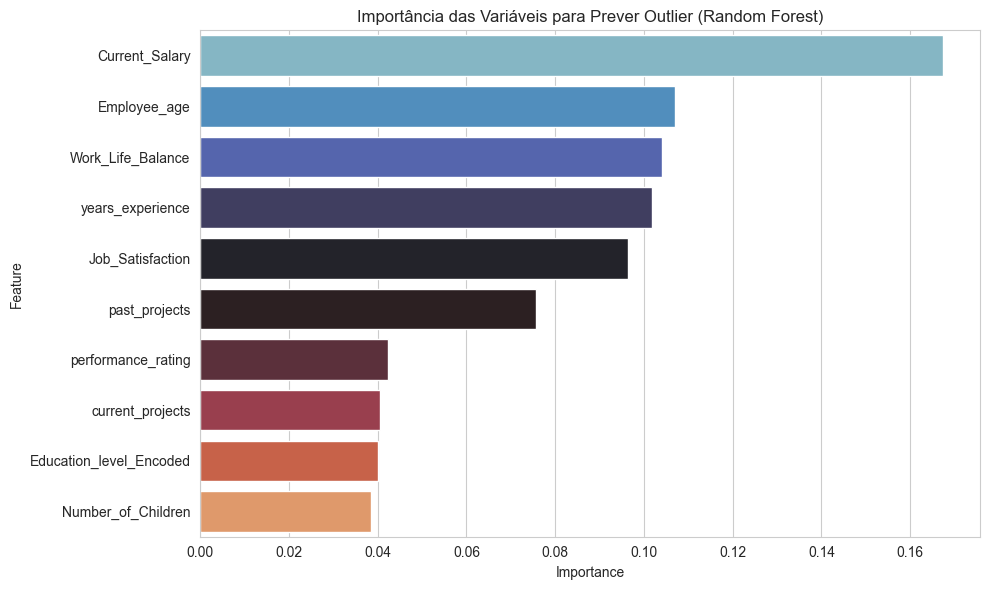

In [12]:
# O rf_model já está treinado.
# X_train já possui o nome das features (colunas).

#Extrair a importância das variáveis
feature_importances = rf_model.feature_importances_

#Mapear para o nome das colunas e ordenar
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

#Exibir as 10 principais
print("10 Variáveis Mais Importantes (Random Forest)")
print(importance_df.head(10))

#Visualização (opcional)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='icefire')
plt.title('Importância das Variáveis para Prever Outlier (Random Forest)')
plt.tight_layout()

In [13]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

ID_COLS = ['Employee_number', 'Employee_name']
OHE_COLS = ['Department', 'Role']
ORDINAL_COL = 'Education_level'
education_mapping = {level: i + 1 for i, level in enumerate(["High School", "Diploma", "Bachelor's", "Master's", "PhD"])}

def preprocess_data(df):
    """Aplica o pré-processamento definido."""
    df['Maritial_Status'] = df['Maritial_Status'].astype(int)
    df['Divorced_earlier'] = df['Divorced_earlier'].map({'Yes': 1, 'No': 0})
    df['Father_alive'] = df['Father_alive'].map({'Yes': 1, 'No': 0})
    df['Mother_alive'] = df['Mother_alive'].map({'Yes': 1, 'No': 0})
    
    if ORDINAL_COL in df.columns:
        df['Education_level_Encoded'] = df[ORDINAL_COL].map(education_mapping)
        df.drop(ORDINAL_COL, axis=1, inplace=True)
    
    #Remover 'is_outlier' do conjunto de Treino se quisermos prever o salário dos dados originais
    #No entanto, a coluna 'is_outlier' é um sinal fortíssimo para o salário e deve ser mantida como feature.
    df.drop(ID_COLS, axis=1, inplace=True, errors='ignore')
    return df

df_train_proc = preprocess_data(df_train.copy())
df_test_proc = preprocess_data(df_test.copy())

#One-Hot Encoding e Alinhamento
df_train_proc = pd.get_dummies(df_train_proc, columns=OHE_COLS, prefix=['Dept', 'Role'], drop_first=True)
df_test_proc = pd.get_dummies(df_test_proc, columns=OHE_COLS, prefix=['Dept', 'Role'], drop_first=True)

#Alinhamento de colunas (garantindo que o teste tenha as mesmas colunas do treino)
train_cols = df_train_proc.drop('Current_Salary', axis=1).columns
df_test_proc = df_test_proc.reindex(columns=train_cols.tolist() + ['Current_Salary'], fill_value=0)


#ESCALONAMENTO DE DADOS

#Definição de Features (X) e Target (y)
X_train = df_train_proc.drop('Current_Salary', axis=1)
y_train = df_train_proc['Current_Salary']
X_test = df_test_proc.drop('Current_Salary', axis=1)
y_test = df_test_proc['Current_Salary']

#Variáveis numéricas para escalonamento (exceto o target)
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()

#Ajustar (fit) o scaler APENAS no treino e Transformar ambos
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])


#TREINAMENTO E AVALIAÇÃO DO MODELO (Random Forest Regressor)

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor.fit(X_train, y_train)

#Predição
y_pred_reg = rf_regressor.predict(X_test)

#Avaliação
rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2 = r2_score(y_test, y_pred_reg)
mean_salary = y_test.mean()

print(f"Avaliação do Random Forest Regressor")
print(f"Salário Médio no Teste: ${mean_salary:,.2f}")
print(f"RMSE (Erro Quadrático Médio da Raiz): ${rmse:,.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")

print("O RMSE representa o erro médio esperado na previsão salarial. Idealmente, ele deve ser pequeno em relação ao salário médio.")

Avaliação do Random Forest Regressor
Salário Médio no Teste: $58,434.36
RMSE (Erro Quadrático Médio da Raiz): $32,342.83
R² (Coeficiente de Determinação): 0.1118
O RMSE representa o erro médio esperado na previsão salarial. Idealmente, ele deve ser pequeno em relação ao salário médio.


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

#CARREGAR DADOS NOVAMENTE PARA ESTADO LIMPO
df_train = pd.read_csv('Employee_Train_Dataset.csv')
df_test = pd.read_csv('Employee_Test_Dataset.csv')

#PRÉ-PROCESSAMENTO E ENCODING PARA CLASSIFICAÇÃO MULTICLASSE

ID_COLS = ['Employee_number', 'Employee_name']
ORDINAL_COL = 'Education_level'
#'Role' é agora a variável-alvo, não está na lista OHE_COLS
NOMINAL_COLS = ['Department'] 
education_mapping = {level: i + 1 for i, level in enumerate(["High School", "Diploma", "Bachelor's", "Master's", "PhD"])}

def preprocess_data_multiclass(df):
    """Aplica o pré-processamento, mantendo 'Role' como categoria."""
    
    # Codificação Binária
    df['Maritial_Status'] = df['Maritial_Status'].astype(int)
    df['Divorced_earlier'] = df['Divorced_earlier'].map({'Yes': 1, 'No': 0})
    df['Father_alive'] = df['Father_alive'].map({'Yes': 1, 'No': 0})
    df['Mother_alive'] = df['Mother_alive'].map({'Yes': 1, 'No': 0})

    #Codificação Ordinal (Education_level)
    if ORDINAL_COL in df.columns:
        df['Education_level_Encoded'] = df[ORDINAL_COL].map(education_mapping)
        df.drop(ORDINAL_COL, axis=1, inplace=True)
    
    #Remoção de IDs e Variável-Alvo Antiga ('is_outlier')
    df.drop(ID_COLS, axis=1, inplace=True, errors='ignore')
    df.drop('is_outlier', axis=1, inplace=True, errors='ignore')

    #One-Hot Encoding apenas para 'Department'
    df = pd.get_dummies(df, columns=NOMINAL_COLS, prefix='Dept', drop_first=True)
    
    return df

df_train_proc = preprocess_data_multiclass(df_train.copy())
df_test_proc = preprocess_data_multiclass(df_test.copy())

#DEFINIÇÃO DE TARGET E ESCALONAMENTO

#A coluna-alvo 'Role' deve ser transformada em números inteiros (Label Encoding)
le = LabelEncoder()
y_train = le.fit_transform(df_train_proc['Role'])
y_test = le.transform(df_test_proc['Role'])

#Remoção da coluna de texto 'Role' dos features
X_train = df_train_proc.drop('Role', axis=1)
X_test = df_test_proc.drop('Role', axis=1)

#Alinhamento de colunas (garantindo que o teste tenha as mesmas colunas do treino)
train_cols = X_train.columns
X_test = X_test.reindex(columns=train_cols, fill_value=0)

#Escalonamento das variáveis numéricas (necessário para alguns modelos, mas mantido para consistência)
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])


#TREINAMENTO DO MODELO (Random Forest Classifier)
#Modelo robusto para multiclasse
rf_multiclass = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_multiclass.fit(X_train, y_train)

#AVALIAÇÃO DO MODELO
y_pred_multiclass = rf_multiclass.predict(X_test)

#Mapear de volta os rótulos numéricos para nomes para o relatório
class_names = le.classes_

print("Relatório de Classificação (Previsão de Função/Role)")
print(classification_report(y_test, y_pred_multiclass, target_names=class_names, zero_division=0))

Relatório de Classificação (Previsão de Função/Role)
                        precision    recall  f1-score   support

     Account Executive       0.45      0.50      0.47       339
               Analyst       0.52      0.54      0.53       361
   Customer Specialist       0.47      0.56      0.51       334
       DevOps Engineer       0.31      0.34      0.32       221
          HR Executive       0.50      0.45      0.47       353
            HR Manager       0.46      0.50      0.48       325
           ML Engineer       0.38      0.42      0.40       253
Operations Coordinator       0.50      0.49      0.49       367
           Ops Manager       0.46      0.48      0.47       342
            Researcher       0.50      0.42      0.46       375
         Sales Manager       0.52      0.47      0.50       394
             Scientist       0.46      0.53      0.49       346
        Senior Analyst       0.51      0.49      0.50       354
     Software Engineer       0.40      0.33      0

10 Variáveis Mais Importantes (Previsão de Função/Role)
              Feature  Importance
12  Work_Life_Balance    0.077711
2      Current_Salary    0.075415
19       Dept_Support    0.074409
18         Dept_Sales    0.073266
14       Dept_Finance    0.072096
16    Dept_Operations    0.071949
11   Job_Satisfaction    0.071740
15            Dept_HR    0.071640
17           Dept_R&D    0.071020
0        Employee_age    0.067187


C:\Users\Usuário\AppData\Local\Temp\ipykernel_14184\2133400545.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='icefire')


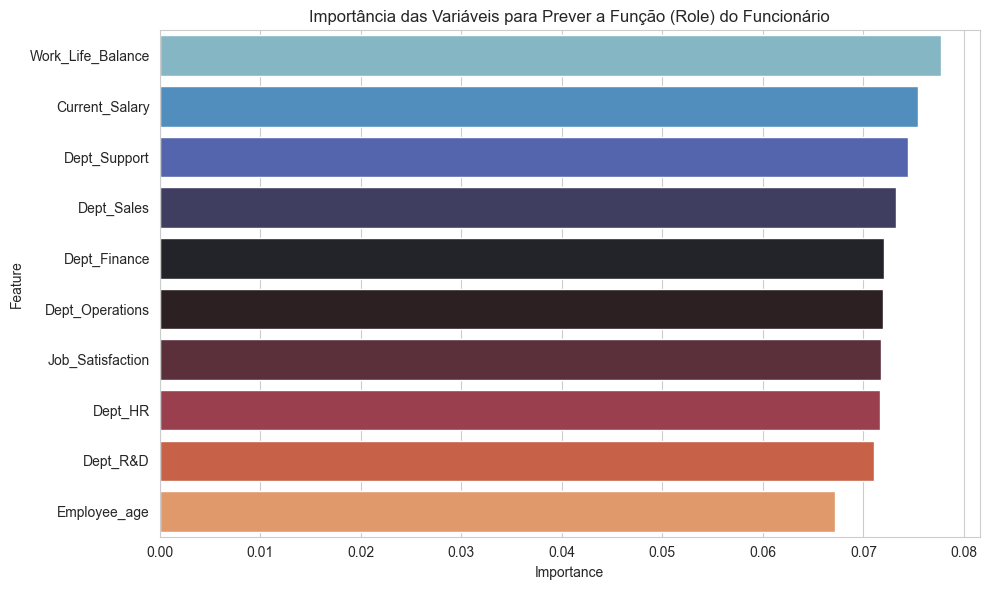

In [15]:
#PRÉ-PROCESSAMENTO E ENCODING PARA CLASSIFICAÇÃO MULTICLASSE

ID_COLS = ['Employee_number', 'Employee_name']
ORDINAL_COL = 'Education_level'
NOMINAL_COLS = ['Department'] 
education_mapping = {level: i + 1 for i, level in enumerate(["High School", "Diploma", "Bachelor's", "Master's", "PhD"])}

def preprocess_data_multiclass(df):
    """Aplica o pré-processamento, mantendo 'Role' como categoria."""
    
    #Codificação Binária
    df['Maritial_Status'] = df['Maritial_Status'].astype(int)
    df['Divorced_earlier'] = df['Divorced_earlier'].map({'Yes': 1, 'No': 0})
    df['Father_alive'] = df['Father_alive'].map({'Yes': 1, 'No': 0})
    df['Mother_alive'] = df['Mother_alive'].map({'Yes': 1, 'No': 0})

    #Codificação Ordinal (Education_level)
    if ORDINAL_COL in df.columns:
        df['Education_level_Encoded'] = df[ORDINAL_COL].map(education_mapping)
        df.drop(ORDINAL_COL, axis=1, inplace=True)
    
    #Remoção de IDs e Variável-Alvo Antiga ('is_outlier')
    df.drop(ID_COLS, axis=1, inplace=True, errors='ignore')
    df.drop('is_outlier', axis=1, inplace=True, errors='ignore')

    #One-Hot Encoding apenas para 'Department'
    df = pd.get_dummies(df, columns=NOMINAL_COLS, prefix='Dept', drop_first=True)
    
    return df

df_train_proc = preprocess_data_multiclass(df_train.copy())
df_test_proc = preprocess_data_multiclass(df_test.copy())

#DEFINIÇÃO DE TARGET E ESCALONAMENTO

#A coluna-alvo 'Role' deve ser transformada em números inteiros (Label Encoding)
le = LabelEncoder()
y_train = le.fit_transform(df_train_proc['Role'])

#Remoção da coluna de texto 'Role' dos features
X_train = df_train_proc.drop('Role', axis=1)
X_test = df_test_proc.drop('Role', axis=1)

#Alinhamento de colunas 
train_cols = X_train.columns
X_test = X_test.reindex(columns=train_cols, fill_value=0)

#Escalonamento das variáveis numéricas
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])


#TREINAMENTO DO MODELO (Random Forest Classifier)
rf_multiclass = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_multiclass.fit(X_train, y_train)

#ANÁLISE DE IMPORTÂNCIA DE VARIÁVEIS
feature_importances = rf_multiclass.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

#Exibir as 10 principais
print("10 Variáveis Mais Importantes (Previsão de Função/Role)")
print(importance_df.head(10))

#Visualização
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='icefire')
plt.title('Importância das Variáveis para Prever a Função (Role) do Funcionário')
plt.tight_layout()

Análise do K-Means: A curva do 'Método Elbow' foi gerada e salva para determinar o K ideal.
Após a determinação, aplicaremos o K-Means e faremos a análise dos grupos.


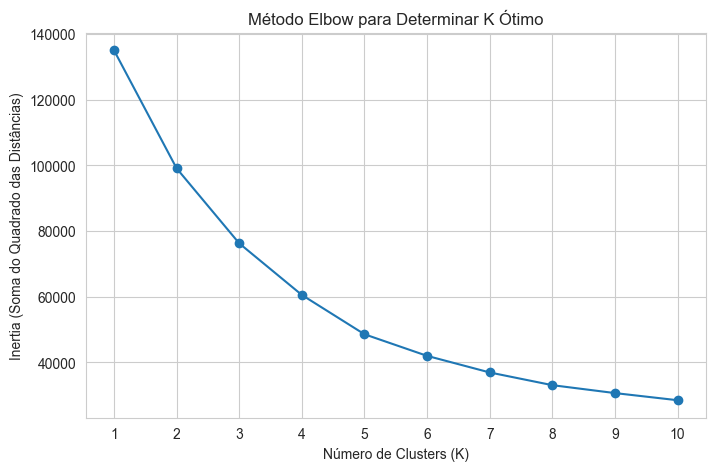

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Dataset de treino completo para o agrupamento, pois ele tem o maior volume de dados.
df_clustering = pd.read_csv('Employee_Train_Dataset.csv')

#Variáveis para o Agrupamento de Comportamento no Trabalho
clustering_cols = ['years_experience', 'past_projects', 'current_projects']

#Pré-processamento básico e focamos nas colunas relevantes
X_clustering = df_clustering[clustering_cols].copy()

#Agrupamento é muito sensível à escala, então escalamos apenas as colunas de Agrupamento.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

#DETERMINAR O NÚMERO ÓTIMO DE CLUSTERS (Método Elbow)
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

#Visualizar o Método Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inertia (Soma do Quadrado das Distâncias)')
plt.title('Método Elbow para Determinar K Ótimo')
plt.xticks(K_range)
plt.grid(True)
print("Análise do K-Means: A curva do 'Método Elbow' foi gerada e salva para determinar o K ideal.")
print("Após a determinação, aplicaremos o K-Means e faremos a análise dos grupos.")

In [17]:
# ariáveis para o Agrupamento de Comportamento no Trabalho
clustering_cols = ['years_experience', 'past_projects', 'current_projects']

#Aplicamos o pré-processamento básico e focamos nas colunas relevantes
X_clustering = df_clustering[clustering_cols].copy()

#Escalonamento das features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_cols)


#APLICAÇÃO DO K-MEANS (Assumindo K=3)
K = 3 #Baseado em uma suposição comum de K=3 para perfis (Baixo/Médio/Alto)
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_clustering['Cluster'] = kmeans.fit_predict(X_scaled_df)

#ANÁLISE DOS CENTROIDES E CARACTERÍSTICAS DO GRUPO
#Encontrando as médias (centroides) de cada cluster nas features originais
cluster_summary = df_clustering.groupby('Cluster')[clustering_cols].mean()

#Incluir outras variáveis-chave para caracterizar os grupos (Salário, Satisfação)
other_cols_for_summary = ['Current_Salary', 'Job_Satisfaction']
full_summary = df_clustering.groupby('Cluster')[clustering_cols + other_cols_for_summary].mean()

print("Caracterização dos 3 Grupos de Comportamento no Trabalho")
print(full_summary.sort_values(by='years_experience'))

Caracterização dos 3 Grupos de Comportamento no Trabalho
         years_experience  past_projects  current_projects  Current_Salary  \
Cluster                                                                      
1                4.353299       7.016043          0.464489    57489.121084   
0                4.457164       6.998780          2.530174    57692.383516   
2               20.753270       7.019432          1.496357    60957.462818   

         Job_Satisfaction  
Cluster                    
1                6.539174  
0                6.533689  
2                6.597384  


In [18]:
df_train = pd.read_csv('Employee_Train_Dataset.csv')
df_test = pd.read_csv('Employee_Test_Dataset.csv')

ID_COLS = ['Employee_number', 'Employee_name']
OHE_COLS = ['Department', 'Role']
ORDINAL_COL = 'Education_level'
education_mapping = {level: i + 1 for i, level in enumerate(["High School", "Diploma", "Bachelor's", "Master's", "PhD"])}

#CRIAÇÃO DA VARIÁVEL-ALVO (Target)
BALANCE_THRESHOLD = 5
def create_wlb_target(df):
    """Cria a variável binária 'is_healthy_wlb'."""
    df['is_healthy_wlb'] = (df['Work_Life_Balance'] > BALANCE_THRESHOLD).astype(int)
    #A coluna original 'Work_Life_Balance' DEVE ser removida dos features (X)
    return df

df_train = create_wlb_target(df_train)
df_test = create_wlb_target(df_test)


#PRÉ-PROCESSAMENTO (Função adaptada)
def preprocess_data_binary(df):
    """Aplica o pré-processamento para a classificação binária."""
    
    #Codificação Binária
    df['Maritial_Status'] = df['Maritial_Status'].astype(int)
    df['Divorced_earlier'] = df['Divorced_earlier'].map({'Yes': 1, 'No': 0})
    df['Father_alive'] = df['Father_alive'].map({'Yes': 1, 'No': 0})
    df['Mother_alive'] = df['Mother_alive'].map({'Yes': 1, 'No': 0})

    #Codificação Ordinal (Education_level)
    if ORDINAL_COL in df.columns:
        df['Education_level_Encoded'] = df[ORDINAL_COL].map(education_mapping)
        df.drop(ORDINAL_COL, axis=1, inplace=True)
    
    #Remoção de IDs e Variável-Alvo Antiga ('is_outlier')
    df.drop(ID_COLS, axis=1, inplace=True, errors='ignore')
    df.drop('is_outlier', axis=1, inplace=True, errors='ignore')

    #One-Hot Encoding para 'Department' e 'Role'
    df = pd.get_dummies(df, columns=OHE_COLS, prefix=['Dept', 'Role'], drop_first=True)
    
    return df

df_train_proc = preprocess_data_binary(df_train.copy())
df_test_proc = preprocess_data_binary(df_test.copy())

#DEFINIÇÃO DE FEATURES (X) E TARGET (y)

#A variável original 'Work_Life_Balance' deve ser removida de X para evitar data leakage.
X_train = df_train_proc.drop(['is_healthy_wlb', 'Work_Life_Balance'], axis=1, errors='ignore')
y_train = df_train_proc['is_healthy_wlb']
X_test = df_test_proc.drop(['is_healthy_wlb', 'Work_Life_Balance'], axis=1, errors='ignore')
y_test = df_test_proc['is_healthy_wlb']

#Alinhamento de colunas
train_cols = X_train.columns
X_test = X_test.reindex(columns=train_cols, fill_value=0)

#Escalonamento das variáveis numéricas
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])


#TREINAMENTO E AVALIAÇÃO DO MODELO (Random Forest Classifier)
rf_wlb = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf_wlb.fit(X_train, y_train)

y_pred_wlb = rf_wlb.predict(X_test)

#AVALIAÇÃO DO MODELO
print("Relatório de Classificação (Previsão de Equilíbrio Saudável)")
print(classification_report(y_test, y_pred_wlb, target_names=['Insatisfatório (<=5)', 'Saudável (>5)']))

print("Matriz de Confusão")
print(confusion_matrix(y_test, y_pred_wlb))

Relatório de Classificação (Previsão de Equilíbrio Saudável)
                      precision    recall  f1-score   support

Insatisfatório (<=5)       0.61      0.92      0.73      2980
       Saudável (>5)       0.52      0.14      0.22      2020

            accuracy                           0.60      5000
           macro avg       0.57      0.53      0.47      5000
        weighted avg       0.58      0.60      0.52      5000

Matriz de Confusão
[[2731  249]
 [1746  274]]


In [19]:
from xgboost import XGBClassifier

ID_COLS = ['Employee_number', 'Employee_name']
ORDINAL_COL = 'Education_level'
NOMINAL_COLS = ['Department'] 
education_mapping = {level: i + 1 for i, level in enumerate(["High School", "Diploma", "Bachelor's", "Master's", "PhD"])}

def preprocess_data_multiclass(df):
    """Aplica o pré-processamento, mantendo 'Role' como categoria."""
    df['Maritial_Status'] = df['Maritial_Status'].astype(int)
    df['Divorced_earlier'] = df['Divorced_earlier'].map({'Yes': 1, 'No': 0})
    df['Father_alive'] = df['Father_alive'].map({'Yes': 1, 'No': 0})
    df['Mother_alive'] = df['Mother_alive'].map({'Yes': 1, 'No': 0})

    if ORDINAL_COL in df.columns:
        df['Education_level_Encoded'] = df[ORDINAL_COL].map(education_mapping)
        df.drop(ORDINAL_COL, axis=1, inplace=True)
    
    df.drop(ID_COLS, axis=1, inplace=True, errors='ignore')
    df.drop('is_outlier', axis=1, inplace=True, errors='ignore')

    df = pd.get_dummies(df, columns=NOMINAL_COLS, prefix='Dept', drop_first=True)
    
    return df

df_train_proc = preprocess_data_multiclass(df_train.copy())
df_test_proc = preprocess_data_multiclass(df_test.copy())

#Label Encoding para o Target 'Role'
le = LabelEncoder()
y_train = le.fit_transform(df_train_proc['Role'])
y_test = le.transform(df_test_proc['Role'])

X_train = df_train_proc.drop('Role', axis=1)
X_test = df_test_proc.drop('Role', axis=1)

train_cols = X_train.columns
X_test = X_test.reindex(columns=train_cols, fill_value=0)

#Escalonamento (opcional para árvores, mas mantido para features numéricas)
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

#TREINAMENTO DO MODELO (XGBoost Classifier)
#Usando objective='multi:softmax' e um número razoável de estimadores
xgb_multiclass = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='merror',
    use_label_encoder=False,
    n_estimators=300, 
    random_state=42, 
    n_jobs=-1
)
xgb_multiclass.fit(X_train, y_train)

#AVALIAÇÃO DO MODELO
y_pred_xgb = xgb_multiclass.predict(X_test)

#Mapear de volta os rótulos numéricos para nomes para o relatório
class_names = le.classes_

print("Relatório de Classificação (Previsão de Função/Role) - XGBoost")
print(classification_report(y_test, y_pred_xgb, target_names=class_names, zero_division=0))

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:32:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Relatório de Classificação (Previsão de Função/Role) - XGBoost
                        precision    recall  f1-score   support

     Account Executive       0.45      0.49      0.47       339
               Analyst       0.51      0.54      0.52       361
   Customer Specialist       0.49      0.53      0.51       334
       DevOps Engineer       0.34      0.38      0.36       221
          HR Executive       0.53      0.50      0.51       353
            HR Manager       0.49      0.52      0.50       325
           ML Engineer       0.34      0.36      0.35       253
Operations Coordinator       0.55      0.53      0.54       367
           Ops Manager       0.51      0.53      0.52       342
            Researcher       0.49      0.45      0.47       375
         Sales Manager       0.53      0.48      0.50       394
             Scientist       0.46      0.50      0.48       346
        Senior Analyst       0.50      0.47      0.48       354
     Software Engineer       0.38      0

# Conclusão Final

**O insight final do projeto:** as características básicas disponíveis (salário, idade, experiência) não são suficientes para distinguir de forma confiável entre as 15 diferentes funções de trabalho.
O sucesso em identificar padrões de comportamento e anomalias (tarefas descritivas/diagnósticas). O fracasso em realizar previsões detalhadas de RH (tarefas preditivas).
Isto não é um fracasso dos modelos, mas um feedback crítico sobre a qualidade e a profundidade dos dados atualmente coletados pela organização.

**O projeto provou que a organização tem dados suficientes para duas ações imediatas e de alto impacto:**

| Ação                                      | Ferramenta                       | O que Fazer                                                                                                                                                                                        |
| ----------------------------------------- | -------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Auditoria e Fraude (Detecção de Outliers) | Random Forest (Precision = 1.00) | Usar o modelo para sinalizar automaticamente funcionários com anomalias financeiras e/ou de satisfação. O custo de investigar um falso positivo é zero.                                            |
| Estratégia de Retenção e Alocação         | K-Means (Agrupamento)            | Intervenção imediata nos grupos de risco: Risco de Burnout — funcionários de baixa experiência com alto volume de projetos. Risco de Turnover/Ociosidade — veteranos com baixo volume de projetos. |
| Fatores de Anomalia                       | Feature Importance               | Salário e Satisfação são os fatores dominantes na definição de um outlier, indicando anomalia financeira mais do que experiência ou desempenho.                                                    |


**Os modelos de Regressão e Classificação para tarefas de alto valor falharam, indicando lacunas críticas na coleta de dados:**

| Tarefa                                                       | Performance                      | Ação de RH Sugerida                                                                                                                                                                                            |
| ------------------------------------------------------------ | -------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Previsão de Salário ($R^2 = 0.11$) / Função (Acurácia = 48%) | Muito Fraca                      | Coleta de dados hierárquicos. Sem a variável Nível Hierárquico (Júnior, Pleno, Sênior, Gestor) e, idealmente, Localização Geográfica, salários e funções continuarão imprevisíveis.                            |
| Previsão de Desempenho (Rating 1–5)                          | Falha Completa (F1-Score = 0.22) | Revisão do processo de avaliação. Se o desempenho não é previsível por métricas objetivas, o sistema de rating pode ser subjetivo. Sugere-se coletar dados sobre metas alcançadas ou competências específicas. |
| Previsão de Equilíbrio Saudável (WLB)                        | Muito Fraca (Recall = 14%)       | Pesquisa de clima. O WLB é subjetivo e difícil de prever numericamente. Deve ser tratado com surveys e instrumentos qualitativos, não com modelagem preditiva.                                                 |


# Estratégica

Implantar Modelos de Diagnóstico (Outlier e Agrupamento) para intervenção imediata. Reformular a Coleta de Dados para incluir variáveis de maior granularidade e de nível hierárquico, permitindo que a próxima iteração de modelagem seja bem-sucedida nas tarefas de Regressão Salarial e Previsão de Desempenho.

# **Nathália Sorg**